In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
import os

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

from FEATURES.features import *
from BACKTEST.backtestCalculateEVS import *
from BACKTEST.backtest import *
from MODELS.SAVED_MODELS import *
from MODELS.teamInfo import *


In [2]:
q10_model = joblib.load('../MODELS/SAVED_MODELS/xgb_q10_modelv1.pkl')
q50_model = joblib.load('../MODELS/SAVED_MODELS/xgb_q50_modelv1.pkl')
q90_model = joblib.load('../MODELS/SAVED_MODELS/xgb_q90_modelv1.pkl')
models = {'q10': q10_model, 'q50': q50_model, 'q90': q90_model}
features = joblib.load('../MODELS/SAVED_MODELS/feature_list.pkl')

In [3]:
pd.set_option('display.max_columns', None)

s25_pts = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
s24_pts = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')

df = pd.concat([s25_pts, s24_pts]).sort_values(by='GAME_DATE')

date = '2024-11-30'

In [4]:
backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')
backtestData = backtestData[(backtestData['BOOKMAKER'] == 'underdog') &  (backtestData['CATEGORY'] == 'player_points')]
trailRun = backtestData[(backtestData['BOOKMAKER'] == 'underdog') &  (backtestData['CATEGORY'] == 'player_points') & (backtestData['GAME_DATE'] == date)]
trailRun

/var/folders/nw/9w4r5hrd05s122kt5hg_t8bw0000gn/T/ipykernel_75814/3569531037.py:1: DtypeWarning: Columns (11,12,14) have mixed types. Specify dtype option on import or set low_memory=False.
  backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')


,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,NAME,CATEGORY,BOOKMAKER,SIDE,LINE,ODDS,HOME_TEAM,AWAY_TEAM,game_id,commence_time,GAME_DATE,period_id,fair_line,fair_odds,OVER/ODDS
20790,20790,20790,20790,Trae Young,player_points,underdog,over,22.5,-137,Charlotte Hornets,Atlanta Hawks,618d92be3ea6080d179e501aebc7f971,2024-11-30T23:10:00Z,2024-11-30,NaN,NaN,NaN,over
20791,20791,20791,20791,Trae Young,player_points,underdog,under,22.5,-137,Charlotte Hornets,Atlanta Hawks,618d92be3ea6080d179e501aebc7f971,2024-11-30T23:10:00Z,2024-11-30,NaN,NaN,NaN,under
20792,20792,20792,20792,Brandon Miller,player_points,underdog,under,26.5,-137,Charlotte Hornets,Atlanta Hawks,618d92be3ea6080d179e501aebc7f971,2024-11-30T23:10:00Z,2024-11-30,NaN,NaN,NaN,under
20793,20793,20793,20793,Bogdan Bogdanovic,player_points,underdog,over,11.5,-137,Charlotte Hornets,Atlanta Hawks,618d92be3ea6080d179e501aebc7f971,2024-11-30T23:10:00Z,2024-11-30,NaN,NaN,NaN,over
20794,20794,20794,20794,Bogdan Bogdanovic,player_points,underdog,under,11.5,-137,Charlotte Hornets,Atlanta Hawks,618d92be3ea6080d179e501aebc7f971,2024-11-30T23:10:00Z,2024-11-30,NaN,NaN,NaN,under
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21086,21086,21086,21086,Daniel Gafford,player_points,underdog,over,10.5,-137,Utah Jazz,Dallas Mavericks,94e37c8227c1196969b7702bea4ea97f,2024-12-01T02:40:00Z,2024-11-30,NaN,NaN,NaN,over
21087,21087,21087,21087,Lauri Markkanen,player_points,underdog,under,21.5,-137,Utah Jazz,Dallas Mavericks,94e37c8227c1196969b7702bea4ea97f,2024-12-01T02:40:00Z,2024-11-30,NaN,NaN,NaN,under
21088,21088,21088,21088,Brice Sensabaugh,player_points,underdog,over,8.5,-137,Utah Jazz,Dallas Mavericks,94e37c8227c1196969b7702bea4ea97f,2024-12-01T02:40:00Z,2024-11-30,NaN,NaN,NaN,over
21089,21089,21089,21089,Daniel Gafford,player_points,underdog,under,10.5,-137,Utah Jazz,Dallas Mavericks,94e37c8227c1196969b7702bea4ea97f,2024-12-01T02:40:00Z,2024-11-30,NaN,NaN,NaN,under


In [ ]:
results = backtestPairs(
    data=df,
    backtestData=backtestData,
    gameDate='2024-12-22',
    models=models,  
    features=features,
    edge_threshold=0.10,  
    top_n=10
)
if not results.empty:
    # Overall metrics
    total_bets = len(results)
    total_wins = results['pair_won'].sum()
    win_rate = results['pair_won'].mean()
    
    # Metrics for recommended bets only
    recommended = results[results['pair_recommendation'] == 1]
    if not recommended.empty:
        rec_total = len(recommended)
        rec_wins = recommended['pair_won'].sum()
        rec_win_rate = recommended['pair_won'].mean()
        
        print(f"\n--- All Bets ---")
        print(f"Total: {total_bets}, Wins: {total_wins}, Win Rate: {win_rate:.2%}")
        print(f"\n--- Recommended Bets (Edge > {results['edge_threshold']}) ---")
        print(f"Total: {rec_total}, Wins: {rec_wins}, Win Rate: {rec_win_rate:.2%}")

In [ ]:
results

,player1,player2,model_side1,model_side2,line1,line2,pred1,pred2,q10_1,q90_1,q10_2,q90_2,actual1,actual2,edge1,edge2,leg1_won,leg2_won,pair_recommendation,pair_won,ev_percent,kelly_full,prob_both,combined_edge,date
0,Kevin Huerter,Peyton Watson,under,over,8.5,5.5,6.22,8.37,1.85,14.04,2.20,14.59,8,5,0.090,0.127,1,0,0,0,41.35,0.207,0.4712,0.109,2024-12-22
1,Aaron Gordon,Peyton Watson,over,over,12.5,5.5,14.88,8.37,6.99,22.92,2.20,14.59,17,5,0.058,0.127,1,0,0,0,34.51,0.173,0.4484,0.092,2024-12-22
2,T.J. McConnell,Peyton Watson,over,over,10.5,5.5,12.32,8.37,4.97,19.52,2.20,14.59,12,5,0.036,0.127,1,0,0,0,29.98,0.150,0.4333,0.082,2024-12-22
3,Kelly Olynyk,Peyton Watson,under,over,7.5,5.5,6.09,8.37,1.10,13.48,2.20,14.59,8,5,0.027,0.127,0,0,0,0,27.94,0.140,0.4265,0.077,2024-12-22
4,Gradey Dick,Peyton Watson,over,over,15.5,5.5,17.44,8.37,8.70,26.70,2.20,14.59,14,5,0.021,0.127,0,0,0,0,26.72,0.134,0.4224,0.074,2024-12-22
5,Kevin Huerter,Aaron Gordon,under,over,8.5,12.5,6.22,14.88,1.85,14.04,6.99,22.92,8,17,0.090,0.058,1,1,0,1,27.51,0.138,0.4250,0.074,2024-12-22
6,Fred VanVleet,Peyton Watson,over,over,15.5,5.5,17.13,8.37,8.55,26.68,2.20,14.59,2,5,0.005,0.127,0,0,0,0,23.26,0.116,0.4109,0.066,2024-12-22
7,Tyrese Haliburton,Peyton Watson,over,over,18.5,5.5,20.02,8.37,10.62,28.62,2.20,14.59,14,5,-0.000,0.127,0,0,0,0,22.22,0.111,0.4074,0.063,2024-12-22
8,Kevin Huerter,T.J. McConnell,under,over,8.5,10.5,6.22,12.32,1.85,14.04,4.97,19.52,8,12,0.090,0.036,1,1,0,1,23.21,0.116,0.4107,0.063,2024-12-22
9,Russell Westbrook,Peyton Watson,over,over,10.5,5.5,11.71,8.37,4.38,19.65,2.20,14.59,21,5,-0.005,0.127,1,0,0,0,21.19,0.106,0.4040,0.061,2024-12-22


## Points

In [ ]:
uniqueDates = sorted(s25_pts['GAME_DATE'].unique())
all_results = []

for i, date in enumerate(uniqueDates, 1):
    print(f"Processing {date}... {i}/{len(uniqueDates)}")
    
    try:
        date_results = backtestPairs(
        data=df,
        backtestData=backtestData,
        gameDate='2024-12-16',
        models=models,  
        features=features,
        edge_threshold=0.05,  # 5% probability edge
        top_n=10
    )
        
        if not date_results.empty:
            all_results.append(date_results)
            print(f"  ✓ Processed {len(date_results)} bets")
        else:
            print(f"  No results for {date}")
        
    except Exception as e:
        print(f"  ✗ Error: {e}")
        continue

# Combine all results
if all_results:
    final_results = pd.concat(all_results, ignore_index=True)
    print(f"\n✓ Complete! Total bets analyzed: {len(final_results)}")



Processing 2024-10-23... 1/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-10-24... 2/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-10-25... 3/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-10-26... 4/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-10-27... 5/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-10-28... 6/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-10-29... 7/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-10-30... 8/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-10-31... 9/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-11-01... 10/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-11-02... 11/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-11-03... 12/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-11-04... 13/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-11-06... 14/162
Processing pair

           COMPREHENSIVE BETTING ANALYSIS

 ALL BETS ANALYSIS:
   Total Bets: 1,409
   Wins: 762
   Hit Rate: 54.08%
   Total Profit: $4,385.00
   Total Staked: $7,045.00
   ROI: 62.24%
   Volatility: $46.90
   Max Drawdown: $-205.00
   Sharpe Ratio: 7.874

 RECOMMENDED BETS ANALYSIS (Edge > 5.5):
   Total Bets: 832
   Wins: 491
   Hit Rate: 59.01%
   Total Profit: $3,205.00
   Total Staked: $4,160.00
   ROI: 77.04%
   Volatility: $40.79
   Max Drawdown: $-90.00
   Sharpe Ratio: 7.295


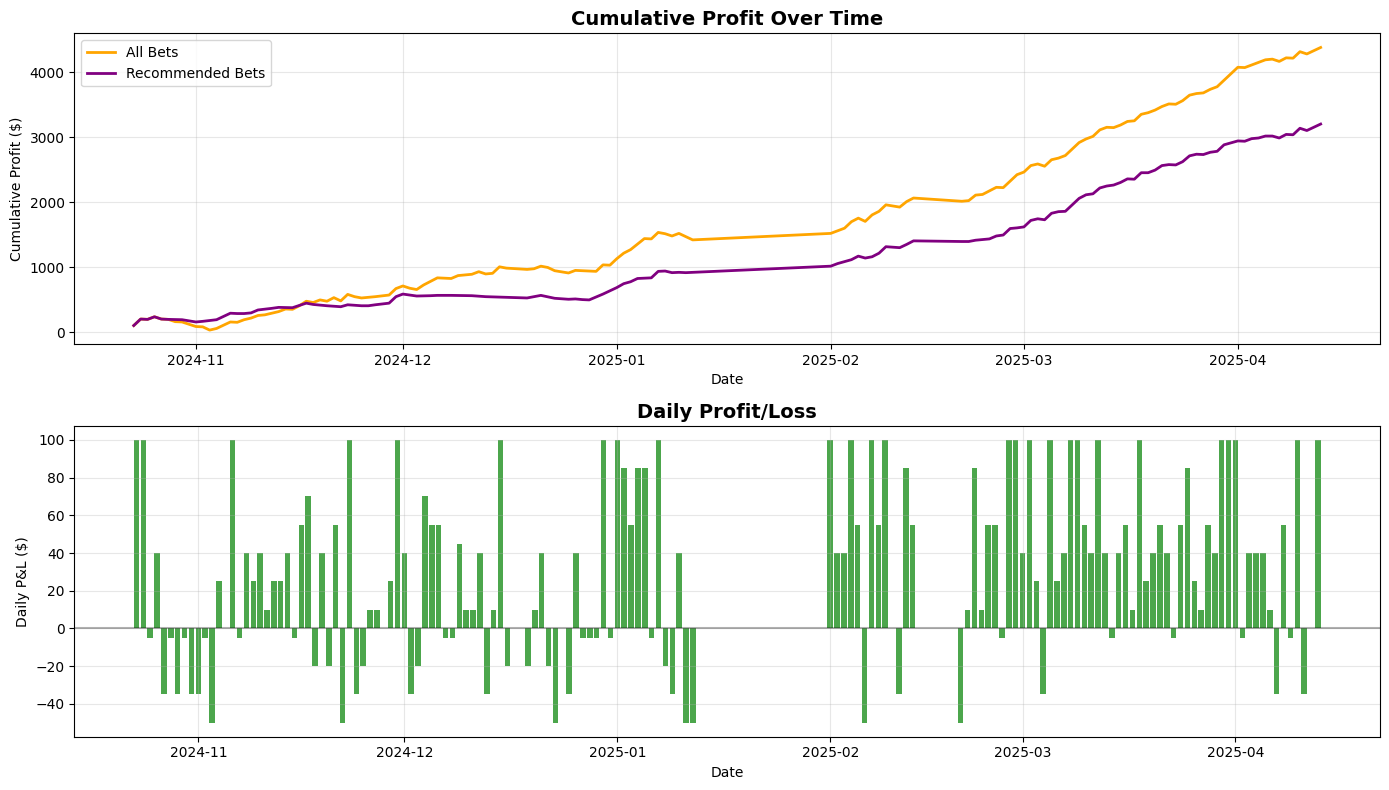

In [8]:
edge = 5.5
# Calculate metrics for all bets
all_metrics = calculatePairMetrics(final_results, stake=5)

# Calculate metrics for recommended bets only
recommended = final_results[final_results['pair_recommendation'] == 1]
rec_metrics = calculatePairMetrics(recommended, stake=5)

# Display comprehensive results
print("=" * 60)
print("           COMPREHENSIVE BETTING ANALYSIS")
print("=" * 60)

if all_metrics:
    print(f"\n ALL BETS ANALYSIS:")
    print(f"   Total Bets: {all_metrics['total_bets']:,}")
    print(f"   Wins: {all_metrics['total_wins']:,}")
    print(f"   Hit Rate: {all_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${all_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${all_metrics['total_staked']:,.2f}")
    print(f"   ROI: {all_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${all_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${all_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {all_metrics['sharpe_ratio']:.3f}")

if rec_metrics:
    print(f"\n RECOMMENDED BETS ANALYSIS (Edge > {edge}):")
    print(f"   Total Bets: {rec_metrics['total_bets']:,}")
    print(f"   Wins: {rec_metrics['total_wins']:,}")
    print(f"   Hit Rate: {rec_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${rec_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${rec_metrics['total_staked']:,.2f}")
    print(f"   ROI: {rec_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${rec_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${rec_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {rec_metrics['sharpe_ratio']:.3f}")

# Plots cumulative profit over time
if all_metrics and not all_metrics['daily_pnl'].empty:
    plt.figure(figsize=(14, 8))
    
    plt.subplot(2, 1, 1)
    plt.plot(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['cumulative_profit'], 
             linewidth=2, label='All Bets', color='orange')
    if rec_metrics and not rec_metrics['daily_pnl'].empty:
        plt.plot(rec_metrics['daily_pnl']['date'], rec_metrics['daily_pnl']['cumulative_profit'], 
                 linewidth=2, label='Recommended Bets', color='purple')
    plt.title('Cumulative Profit Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Profit ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 1, 2)
    plt.bar(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['profit'], 
            alpha=0.7, label='Daily P&L', color='green')
    plt.title('Daily Profit/Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Daily P&L ($)')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()